# TOPIC: Simple Linear Regression.

### 1. Foundations & Model Core
- Continuous Target (y)
- Hypothesis Function
- Weight/Coefficient
- Bias/Intercept
- Lines of Best Fit

### 2. Optimization & Loss Metrics
- Ordinary Least Squares (OLS)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

### 3. Validation & Evaluation Techniques
- Validation Technique (Train-Test Split, K-Fold Cross Validation)
- Evaluations Technique

### 4. Overfitting Control & Tuning
- Underfitting/Overfitting
- L1 and L2 Regularization
- Regularization Parameter

### 5. Advanced Extensions
- Multi-Linear Regression
- Polynomial Regression

## A. Load and Exploratory Dataset Analysis. ##

In the first section of Part A, using .info(), .describe(), and isnull().sum() for checking dataset's structure, verifying that there are no missing values (all 10,000 entries are complete across Gender, Height, and Weight), and examine the basic statistical distribution (mean, standard deviation, min, max, and quartiles) of the numerical features.

In [ ]:
#-- Import Python Library. --#
import pandas as pd
#-- Import .csv file. --#
weight_height = pd.read_csv('weight-height.csv')
weight_height

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [ ]:
print(f"Number of Rows: {weight_height.shape[0]}")
print(f"Number of Columns: {weight_height.shape[1]}")
print(f"Column Names: {weight_height.columns}")

Number of Rows: 10000
Number of Columns: 3
Column Names: Index(['Gender', 'Height', 'Weight'], dtype='object')


In [ ]:
print(f"Data Information: {weight_height.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB
Data Information: None


In [ ]:
weight_height.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [ ]:
weight_height.isnull().sum()

,0
Gender,0
Height,0
Weight,0


Next, using Histograms to showcase the frequency distribution of continuous features (Height and Weight) helps us visualize whether the data follows a normal distribution, identify the central tendencies, and detect any potential outliers or skews in the dataset.

Text(0, 0.5, 'Frequency')

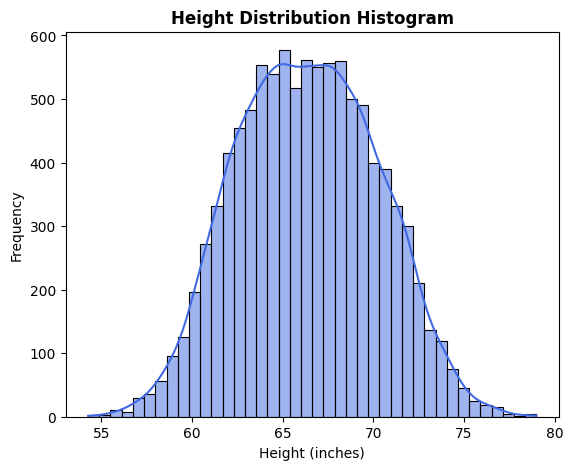

In [ ]:
#-- Histogram for height. --#
import matplotlib.pyplot as plt
import seaborn as sns
#-- Initiate a figure with custom size. --#
plt.figure(figsize=(14, 5))
#-- Select the first subplot. --#
plt.subplot(1, 2, 1)
#-- Draw the histogram plot. --#
#-- In this case, there are four parameters including: --#
#-- weight_height["Height"] is data for drawing. --#
#-- kde=True means showing an additional KDE (Kernel Density Estimation) curve to visualize a smoother data distribution. --#
#-- bins mean divide the data range into 30 intervals, with each interval represented by a bar. --#
sns.histplot(weight_height["Height"], kde=True, color="royalblue", bins=40)
#-- Set the Title, X-axis, and Y-Axis Title. --#
plt.title("Height Distribution Histogram", fontsize=12, fontweight="bold")
plt.xlabel("Height (inches)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)

Text(0, 0.5, 'Frequency')

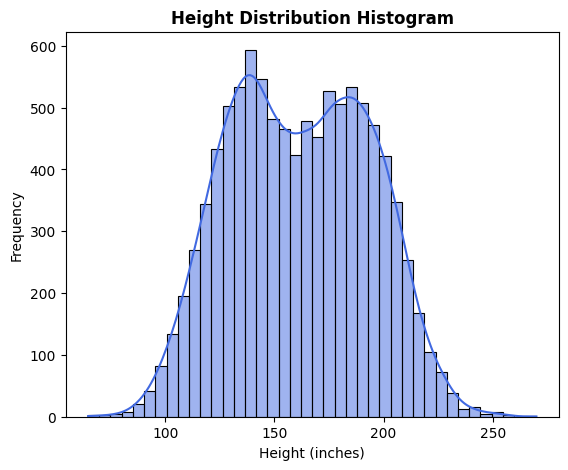

In [ ]:
#-- Histogram for weigh. --#
import matplotlib.pyplot as plt
import seaborn as sns
#-- Initiate a figure with custom size. --#
plt.figure(figsize=(14, 5))
#-- Select the first subplot. --#
plt.subplot(1, 2, 1)
#-- Draw the histogram plot. --#
#-- In this case, there are four parameters including: --#
#-- weight_height["Height"] is data for drawing. --#
#-- kde=True means showing an additional KDE (Kernel Density Estimation) curve to visualize a smoother data distribution. --#
#-- bins mean divide the data range into 30 intervals, with each interval represented by a bar. --#
sns.histplot(weight_height["Weight"], kde=True, color="royalblue", bins=40)
#-- Set the Title, X-axis, and Y-Axis Title. --#
plt.title("Height Distribution Histogram", fontsize=12, fontweight="bold")
plt.xlabel("Height (inches)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)

## B. Feature Selection and Train-Test Split. ##

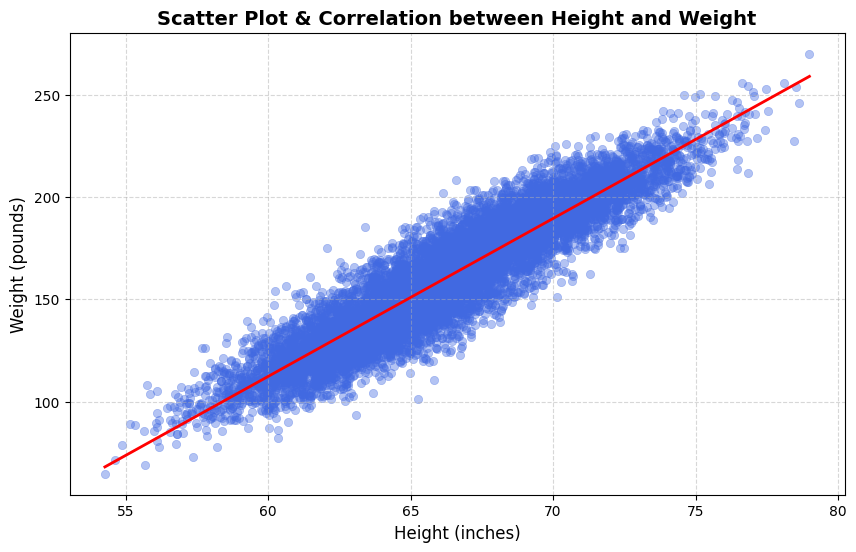

In [ ]:
# 2. Create a scatter plot with a trend line (regression line)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=weight_height, x="Height", y="Weight", alpha=0.4, color="royalblue",edgecolor=None)
# Add trend recovery line (Regression line model)
sns.regplot(data=weight_height, x="Height", y="Weight", scatter=False, color="red", line_kws={"linewidth": 2})
#-- Set Title, X and Y Label. --#
plt.title("Scatter Plot & Correlation between Height and Weight", fontsize=14, fontweight="bold",)
plt.xlabel("Height (inches)", fontsize=12)
plt.ylabel("Weight (pounds)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
#-- Showcase the graph. --#
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
#-- Define X and y Feature. --#
X = weight_height[["Height"]]
y = weight_height["Weight"]
#-- Split Train and Test Dataset. --#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
#-- Check size of the Dataset. --#
print(f"Kích thước tập Train: {X_train.shape[0]} dòng")
print(f"Kích thước tập Test: {X_test.shape[0]} dòng")

Kích thước tập Train: 8000 dòng
Kích thước tập Test: 2000 dòng


## C. Train Model ##

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## D. Test Model and Evaluate. ##

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([210.36368685, 158.5975579 , 167.84192778, ...,  98.8947703 ,
       189.92537022, 157.79896041])

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8513618855632978


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 153.07713353969558


In [ ]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 12.372434422525568


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 9.910378101280832


## E. Evaluation. ##

In [ ]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 7.72250588711404
Intercept: -351.0258752868749


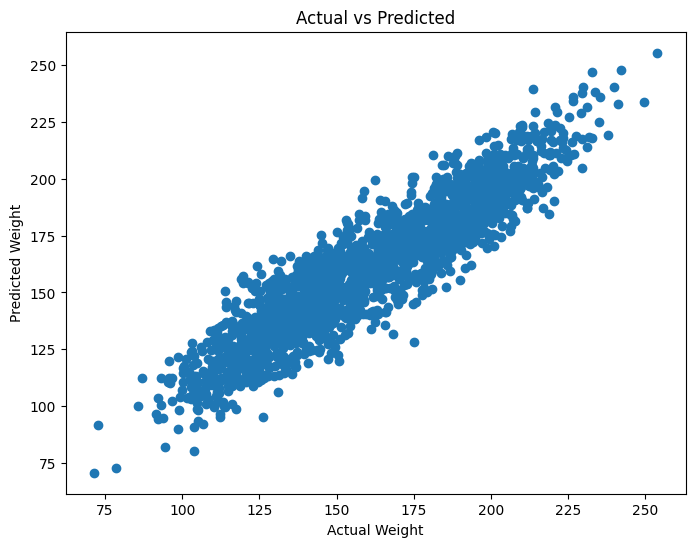

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")
plt.title("Actual vs Predicted")

plt.show()

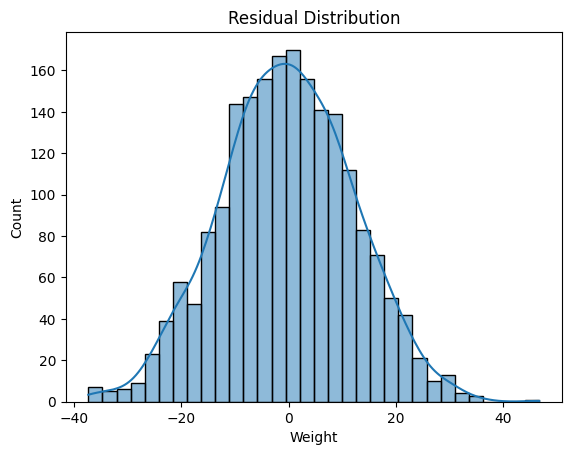

In [ ]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.show()